# Data 2. NOAA OISST (Optimum Interpolation Sea Surface Temperature)
- 다양한 플랫폼(위성, 선박, 부표)에서 편향 조정된 관측치를 정규 글로벌 그리드에 결합하여 구성된 완전한 해양 온도 필드를 제공
- 1일의 지연 시간이 있는 거의 실시간 예비 버전이 출시되고, 14일의 지연 시간이 있는 최종 버전이 출시
- 최종 버전은 예비 버전을 대체하는 것 외에도 평활화를 위한 추가 일수와 구역 편향 보정을 사용
- 해상도 : 0.25 deg

## 추출된 변수
- SST (Sea Surface Temperature) 변수를 Daily > Monthly로 변환
- 평년(1991~2020년) 평균 및 표준편차를 월별로 미리 계산
- 아래 기후 인덱스를 계산
  - NINO 3.4 : 태평양 특정 해역(5N-5S, 170W-120W)의 Anomaly
  - IOD : West Anomaly (50E-70E, 10S-10N) - East Anomaly (90E-110E, 10S-0S)
  - Western V Gradient : Standardized(WP) - Standardized(Nino4)
    - Western Pacific (WP): 130E-150E, 0-20N
    - Nino 4 (Central Pacific): 160E-150W, 5S-5N

In [ ]:
import ee

# ⚠️ 중요: 아래에 사용 중인 Google Cloud Project ID를 입력해야 합니다.
# GEE Code Editor (https://code.earthengine.google.com/) 우측 상단 등에서 확인 가능합니다.
project_id = 'wfp-project-486106'

# GEE 인증 및 초기화
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

In [ ]:
# ==========================================
# 🚀 사용자 설정
# ==========================================
# 분석 기간
TARGET_START = '2007-01-01'
TARGET_END = '2025-12-31'

# 평년 기준 (Anomaly 계산용)
REF_START = '1991-01-01'
REF_END = '2020-12-31'

# 내보낼 파일명
EXPORT_DESC = 'Climate_Indices_OISST_2007_2025'
# ==========================================

In [ ]:
# 1. 지역 정의 (Geometry Definitions)
# (1) NINO 3.4 (태평양): 5N-5S, 170W-120W
nino34_geom = ee.Geometry.Rectangle([-170, -5, -120, 5], 'EPSG:4326', False)

# (2) IOD (인도양)
# West Pole: 50E-70E, 10S-10N
iod_west_geom = ee.Geometry.Rectangle([50, -10, 70, 10], 'EPSG:4326', False)
# East Pole: 90E-110E, 10S-0S
iod_east_geom = ee.Geometry.Rectangle([90, -10, 110, 0], 'EPSG:4326', False)

# (3) Western V Gradient (동아프리카 가뭄 연관)
# Western Pacific (WP): 130E-150E, 0-20N
wp_geom = ee.Geometry.Rectangle([130, 0, 150, 20], 'EPSG:4326', False)
# Nino 4 (Central Pacific): 160E-150W, 5S-5N (날짜변경선 통과 주의)
# GEE에서 날짜변경선을 넘는 사각형은 두 개로 쪼개서 합치는 게 안전함
nino4_geom = ee.Geometry.Polygon([
    [160, -5], [180, -5], [180, 5], [160, 5] # 160E ~ 180
]).union(ee.Geometry.Polygon([
    [-180, -5], [-150, -5], [-150, 5], [-180, 5] # -180 ~ -150W
]))

In [ ]:
# ---------------------------------------------------------
# [수정됨] 2. 데이터셋 로드 및 전처리 (단위 변환 추가)
# ---------------------------------------------------------
# OISST 원본 데이터가 0.01도 단위의 정수(Int16)일 수 있으므로,
# 불러올 때 명시적으로 0.01을 곱해 섭씨(°C) 실수(Float)로 변환합니다.

def load_and_scale(img):
    # sst 밴드에 0.01을 곱함
    return img.multiply(0.01) \
              .copyProperties(img, ['system:time_start']) # 날짜 정보 유지

oisst_raw = ee.ImageCollection("NOAA/CDR/OISST/V2_1").select('sst')
oisst_daily = oisst_raw.map(load_and_scale)

# 이후 to_monthly 함수 등은 그대로 사용하면 됩니다.
def to_monthly(start_date, end_date):
    """지정된 기간 동안 월별 평균 이미지를 생성하는 함수"""
    n_months = ee.Date(end_date).difference(ee.Date(start_date), 'month').round()

    def make_monthly(n):
        date = ee.Date(start_date).advance(n, 'month')
        month_img = oisst_daily.filterDate(date, date.advance(1, 'month')).mean()
        return month_img.set('system:time_start', date.millis())

    return ee.ImageCollection(ee.List.sequence(0, n_months.subtract(1)).map(make_monthly))

In [ ]:
# 3. 평년값(Climatology) 계산 (1991-2020)
# 각 지역별로 월별(1~12월) 평균과 표준편차를 미리 구해둡니다.
# (Western V Gradient는 '표준화된' 편차를 쓰므로 StdDev가 필수입니다)

ref_monthly_col = to_monthly(REF_START, REF_END)

climatology = []
for m in range(1, 13):
    # 해당 월만 필터링
    m_col = ref_monthly_col.filter(ee.Filter.calendarRange(m, m, 'month'))

    # 각 지역별 Mean & Std 계산 (reduceRegion 사용)
    def get_stats(geom, name):
        mean_val = m_col.mean().reduceRegion(ee.Reducer.mean(), geom, 25000).get('sst')
        std_val = m_col.map(lambda img: img).reduce(ee.Reducer.stdDev()) \
                       .reduceRegion(ee.Reducer.mean(), geom, 25000).get('sst_stdDev')
        return {f'{name}_mean': mean_val, f'{name}_std': std_val}

    stats = {'month': m}
    stats.update(get_stats(nino34_geom, 'nino34'))
    stats.update(get_stats(iod_west_geom, 'iod_w'))
    stats.update(get_stats(iod_east_geom, 'iod_e'))
    stats.update(get_stats(wp_geom, 'wp'))
    stats.update(get_stats(nino4_geom, 'nino4'))

    climatology.append(stats)

In [ ]:
# 4. 타겟 기간(2007-2025) 지수 산출
target_monthly_col = to_monthly(TARGET_START, TARGET_END)

# Climatology 리스트를 GEE 객체로 변환 (서버 사이드 접근용)
ee_climatology = ee.List(climatology)

def calculate_indices(img):
    date = img.date()
    m = date.get('month')

    # 해당 월의 Climatology 가져오기
    # List.get()은 0부터 시작하므로 m-1
    clim = ee.Dictionary(ee_climatology.get(m.subtract(1)))

    # (1) 현재 SST 값 추출 (지역별)
    def get_val(geom): return img.reduceRegion(ee.Reducer.mean(), geom, 25000).get('sst')

    sst_n34 = ee.Number(get_val(nino34_geom))
    sst_iod_w = ee.Number(get_val(iod_west_geom))
    sst_iod_e = ee.Number(get_val(iod_east_geom))
    sst_wp = ee.Number(get_val(wp_geom))
    sst_n4 = ee.Number(get_val(nino4_geom))

    # (2) Anomaly 및 지수 계산

    # NINO 3.4 Anomaly (단순 편차)
    nino34_anom = sst_n34.subtract(clim.get('nino34_mean'))

    # IOD (Dipole Mode Index) = West Anomaly - East Anomaly
    # (DMI는 보통 Anomaly 간의 차이로 정의됨)
    iod_w_anom = sst_iod_w.subtract(clim.get('iod_w_mean'))
    iod_e_anom = sst_iod_e.subtract(clim.get('iod_e_mean'))
    dmi = iod_w_anom.subtract(iod_e_anom)

    # Western V Gradient (WVG) = Standardized(WP) - Standardized(Nino4)
    # WVG는 '표준화(Z-score)'된 값의 차이를 사용함 (Funk et al.)
    # WVG가 높음(+) -> 서태평양 온난, 중태평양 한랭 (La Nina 경향) -> 동아프리카 가뭄 유발
    wp_z = sst_wp.subtract(clim.get('wp_mean')).divide(clim.get('wp_std'))
    nino4_z = sst_n4.subtract(clim.get('nino4_mean')).divide(clim.get('nino4_std'))
    wvg = wp_z.subtract(nino4_z)

    # (3) 결과 반환 (Feature)
    return ee.Feature(None, {
        'system:time_start': date.millis(),
        'date': date.format('YYYY-MM-dd'),
        'month': m,
        'NINO34_Anom': nino34_anom,
        'IOD_DMI': dmi,
        'Western_V_Gradient': wvg,
        # 참고용 원본 Anomaly
        'IOD_West_Anom': iod_w_anom,
        'IOD_East_Anom': iod_e_anom,
        'WP_Z_Score': wp_z,
        'Nino4_Z_Score': nino4_z
    })

# 전체 기간에 적용
indices_col = target_monthly_col.map(calculate_indices)

In [ ]:
# 5. CSV 내보내기
task = ee.batch.Export.table.toDrive(
    collection=indices_col,
    description=EXPORT_DESC,
    folder='GEE_Climate_Indices', # 폴더명
    fileFormat='CSV'
)

task.start()
print(f"🚀 Climate Indices 추출 시작: {EXPORT_DESC}")
print("구글 드라이브 'GEE_Climate_Indices' 폴더에 CSV 파일이 생성됩니다.")

🚀 Climate Indices 추출 시작: Climate_Indices_OISST_2007_2025
구글 드라이브 'GEE_Climate_Indices' 폴더에 CSV 파일이 생성됩니다.


In [ ]:
# 작업 상태 확인
tasks = ee.batch.Task.list()

print("=== GEE 작업 목록 ===")
for task in tasks[:5]:
    # 작업 설명, 상태, ID 출력
    print(f"[{task.config['description']}] : {task.state}")

    # 만약 에러가 났다면 에러 메시지 출력
    if task.state == 'FAILED':
        print(f"  ❌ 에러 원인: {task.status()['error_message']}")

=== GEE 작업 목록 ===
[Climate_Indices_OISST_2007_2025] : READY
[Climate_Indices_OISST_2007_2025] : COMPLETED
[Climate_Indices_OISST_2007_2025] : COMPLETED
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2025] : COMPLETED
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2024] : COMPLETED


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive')

# GEE 코드에서 설정한 폴더명과 파일명
folder_path = '/content/drive/MyDrive/GEE_Climate_Indices'
file_name = 'Climate_Indices_OISST_2007_2025.csv'
full_path = os.path.join(folder_path, file_name)

# 데이터 로드 및 검증
if not os.path.exists(full_path):
    print(f"❌ 파일을 찾을 수 없습니다: {full_path}")
    print("GEE 작업이 아직 완료되지 않았거나 경로가 다를 수 있습니다.")
else:
    print(f"✅ 파일을 찾았습니다! 검증을 시작합니다.\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 파일을 찾았습니다! 검증을 시작합니다.



In [ ]:
# CSV 읽기
df = pd.read_csv(full_path)

# 날짜 형식 변환 및 정렬
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
else:
    print("⚠️ 'date' 컬럼이 없습니다. GEE 스크립트를 확인해주세요.")

In [ ]:
# [검증 1] 데이터 개수 및 결측치 확인
total_months = len(df)
expected_months = (2025 - 2007 + 1) * 12 # 19년 * 12개월 = 228개

print(f"--- [1] 데이터 현황 ---")
print(f"총 데이터 개수: {total_months}개 (예상: {expected_months}개)")
print(f"데이터 기간: {df['date'].min().strftime('%Y-%m')} ~ {df['date'].max().strftime('%Y-%m')}")

missing_cnt = expected_months - total_months
if missing_cnt == 0:
    print("✅ 기간 내 누락된 달이 없습니다.")
else:
    print(f"⚠️ {missing_cnt}개의 달이 누락되었습니다.")

--- [1] 데이터 현황 ---
총 데이터 개수: 228개 (예상: 228개)
데이터 기간: 2007-01 ~ 2025-12
✅ 기간 내 누락된 달이 없습니다.


In [ ]:
# [검증 2] 연도별 데이터 개수 (모두 12개여야 함)
print(f"\n--- [2] 연도별 데이터 개수 확인 ---")
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

if (year_counts != 12).any():
    print("⚠️ 주의: 데이터가 12개가 아닌 연도가 있습니다!")
    print(year_counts[year_counts != 12])


--- [2] 연도별 데이터 개수 확인 ---
year
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: count, dtype: int64


In [ ]:
# [검증 3] 주요 변수 값 범위 확인 (이상치 탐지)
cols_to_check = ['NINO34_Anom', 'IOD_DMI', 'Western_V_Gradient']
print(f"\n--- [3] 주요 변수 요약 통계 ---")
print(df[cols_to_check].describe().loc[['min', 'max', 'mean']])


--- [3] 주요 변수 요약 통계 ---
      NINO34_Anom   IOD_DMI  Western_V_Gradient
min     -1.624260 -1.169778           -2.449199
max      2.809232  1.834550            3.024573
mean    -0.028542  0.030714            0.686918


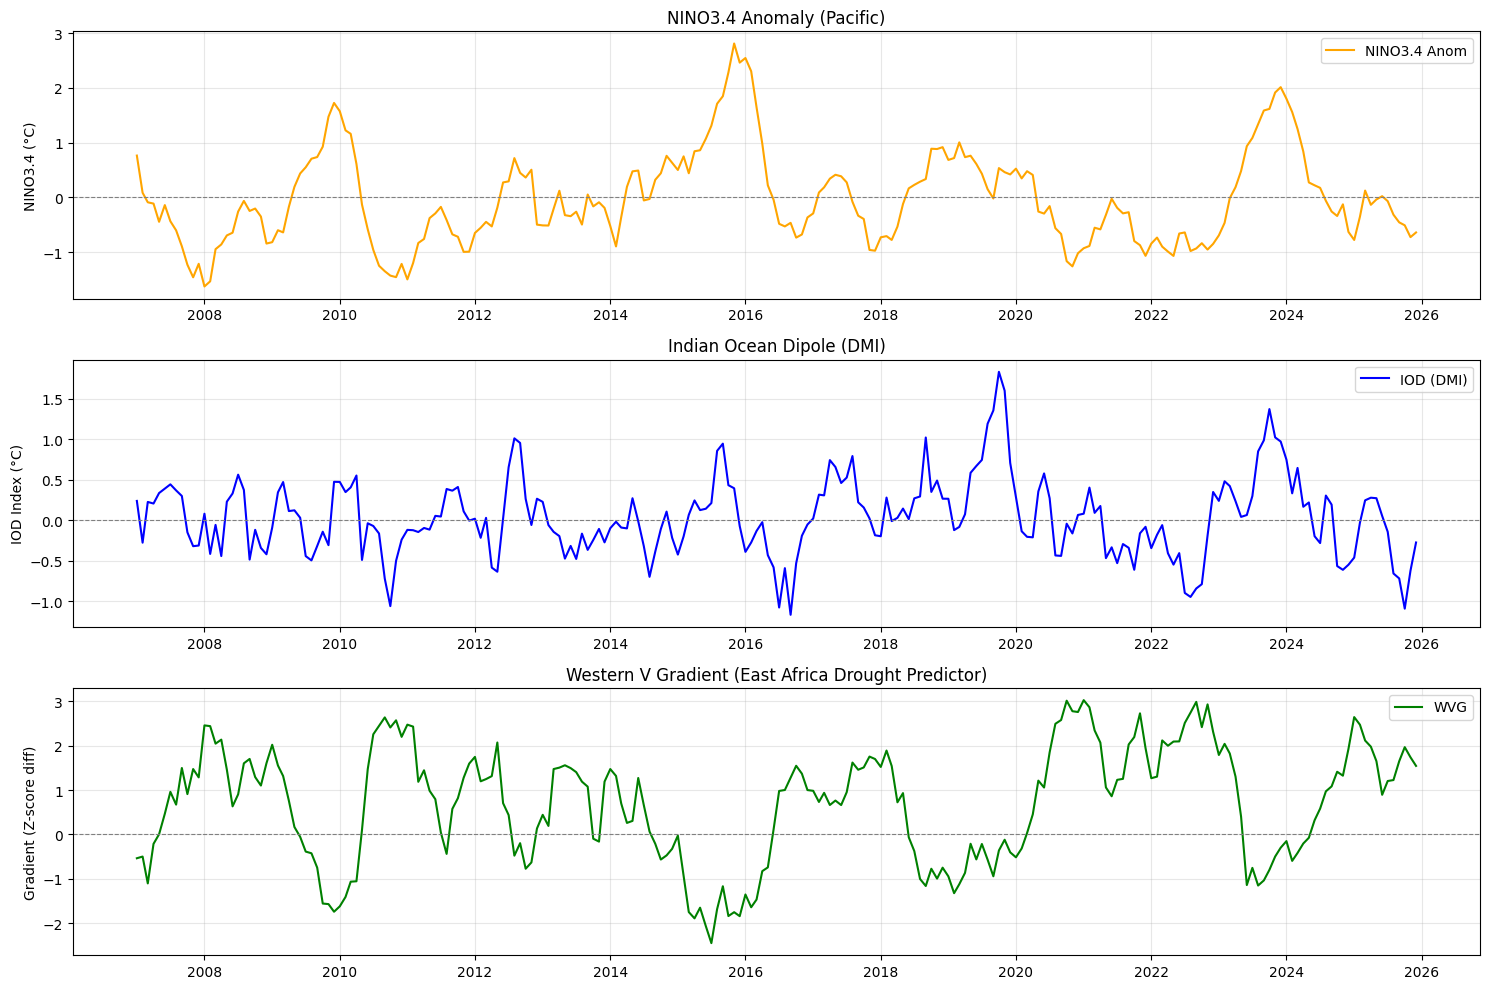


--- [Tip] 가장 최근 데이터 5개 ---
          date  NINO34_Anom   IOD_DMI  Western_V_Gradient
223 2025-08-01    -0.314572 -0.658915            1.224383
224 2025-09-01    -0.454542 -0.720125            1.647421
225 2025-10-01    -0.508228 -1.093723            1.965747
226 2025-11-01    -0.724067 -0.624108            1.737593
227 2025-12-01    -0.638791 -0.275593            1.543493


In [ ]:
# [검증 4] 시계열 시각화 (끊김 여부 눈으로 확인)
plt.figure(figsize=(15, 10))

# NINO3.4
plt.subplot(3, 1, 1)
plt.plot(df['date'], df['NINO34_Anom'], color='orange', label='NINO3.4 Anom')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel('NINO3.4 (°C)')
plt.title('NINO3.4 Anomaly (Pacific)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# IOD
plt.subplot(3, 1, 2)
plt.plot(df['date'], df['IOD_DMI'], color='blue', label='IOD (DMI)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel('IOD Index (°C)')
plt.title('Indian Ocean Dipole (DMI)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Western V Gradient
plt.subplot(3, 1, 3)
plt.plot(df['date'], df['Western_V_Gradient'], color='green', label='WVG')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel('Gradient (Z-score diff)')
plt.title('Western V Gradient (East Africa Drought Predictor)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# [Tip] 최근 데이터 확인
print("\n--- [Tip] 가장 최근 데이터 5개 ---")
print(df[['date', 'NINO34_Anom', 'IOD_DMI', 'Western_V_Gradient']].tail())